## Simulating Spatial Autocorrelation with RADIAN

In [1]:
import geopandas as gpd



In [123]:

hp = gpd.read_file("geojson/radian_hp.geojson").drop(['id'], axis=1).to_crs(3857)
hp['id'] = hp.index+1
dublin = gpd.read_file("geojson/dublin.geojson").to_crs(3857)
print(hp.length)

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
3995    0.0
3996    0.0
3997    0.0
3998    0.0
3999    0.0
Length: 4000, dtype: float64


In [3]:
# Import required packages
import matplotlib as mpl
from matplotlib import colors

%matplotlib inline
mpl.rcParams['figure.figsize'] = (15, 10) #this increases the inline figure size to 15 tall x 10 wide

import seaborn
import pandas as pd
import geopandas as gpd
import pysal
import numpy as np
import mapclassify
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore') # Change settings so that warnings are not displayed

# Loading a few new packages
import contextily as cx
from shapely.geometry import Polygon
import plotly.express as px
import libpysal.weights
import esda
from libpysal import weights
from splot.esda import plot_moran
from splot.esda import moran_scatterplot
from splot.esda import plot_local_autocorrelation
from splot.esda import lisa_cluster
from esda.moran import Moran_Local

In [4]:
xmin,ymin,xmax,ymax =  hp.total_bounds
length = 500
wide = 500

cols = list(np.arange(xmin, xmax + wide, wide))
rows = list(np.arange(ymin, ymax + length, length))

polygons = []
for x in cols[:-1]:
    for y in rows[:-1]:
        polygons.append(Polygon([(x,y), (x+wide, y), (x+wide, y+length), (x, y+length)]))

grid = gpd.GeoDataFrame({'geometry':polygons})

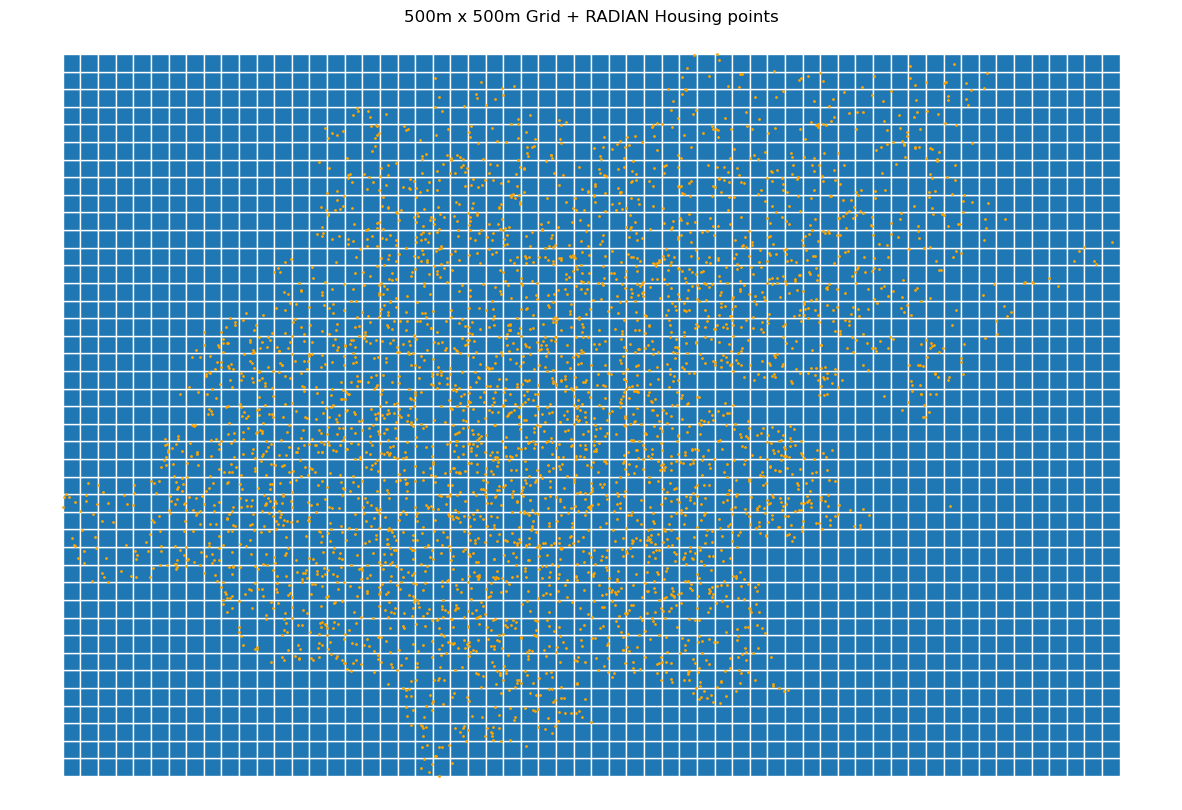

In [5]:
f, ax = plt.subplots(1, figsize=(15, 10)) #Subplots allows you to draw multiple plots in one figure
grid.plot(ax=ax, legend=False, edgecolor='white')
hp.plot(ax=ax, color='orange', markersize=1, alpha=1)
ax.set_axis_off() #Remove axes from plot 
ax.set_title('500m x 500m Grid + RADIAN Housing points') #Plot title text
plt.axis('equal') #Set x and y axes to be equal size
plt.show()

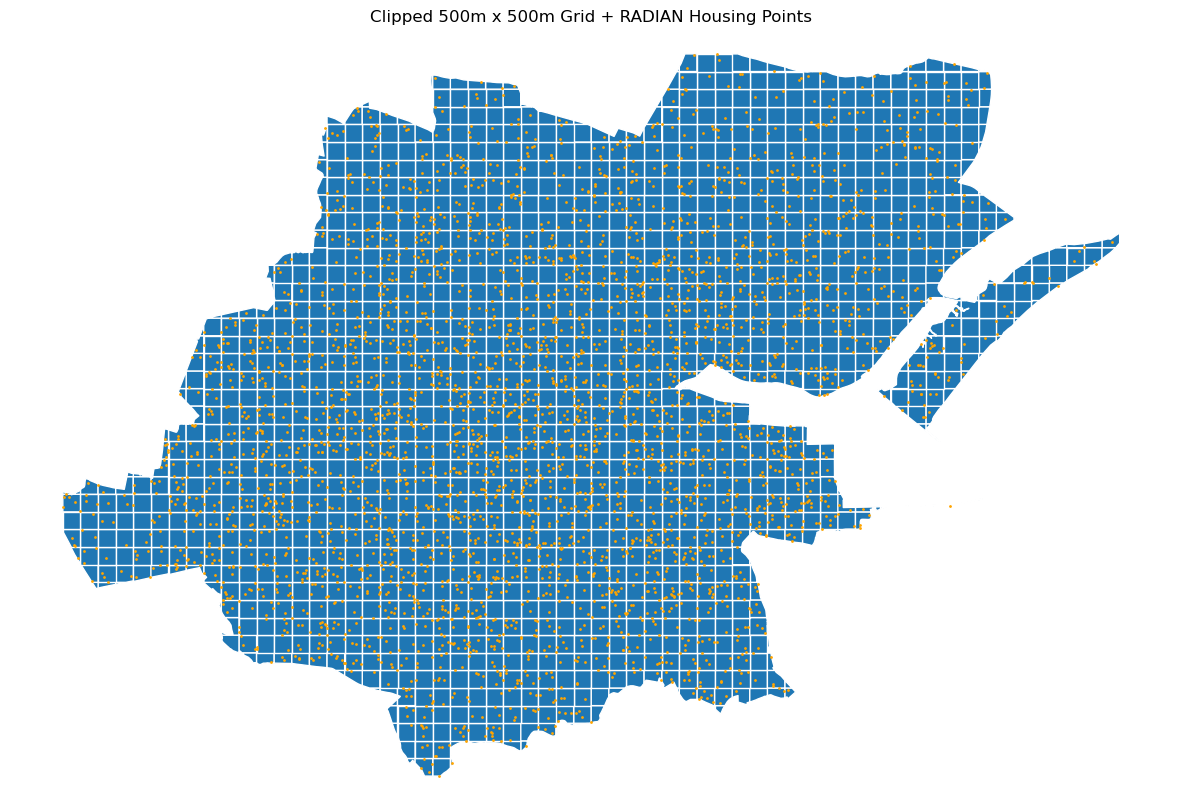

In [6]:
grid_clip = gpd.clip(grid, dublin) #Clip the grid to the extent of the London boroughs GeoJSON

f, ax = plt.subplots(1, figsize=(15, 10)) #Subplots allows you to draw multiple plots in one figure
grid_clip.plot(ax=ax, legend=False, edgecolor='white')
hp.plot(ax=ax, color='orange', markersize=1, alpha=1)
ax.set_axis_off() #Remove axes from plot 
ax.set_title('Clipped 500m x 500m Grid + RADIAN Housing Points') #Plot title text
plt.axis('equal') #Set x and y axes to be equal size
plt.show()

In [7]:
grid_clip['ID2'] = grid_clip.index+1
hp2 = gpd.sjoin(hp,grid_clip)
hp3 = hp2.groupby('ID2').agg({'housePrice':'median','id':'count'})
hp3.columns = ['MedianPrice','House_Count']
hp3 = hp3.reset_index()

grid_clip2 = grid_clip.merge(hp3, how='outer')
grid_clip2['MedianPrice'] = grid_clip2['MedianPrice'].fillna(0) #Fill median house price NAs w/0
grid_clip2['House_Count'] = grid_clip2['House_Count'].fillna(0) #Fill house count NAs w/0
grid_clip2 = grid_clip2.set_crs(epsg=3857)
grid_clip2.to_crs(epsg=4326)

,geometry,ID2,MedianPrice,House_Count
0,"POLYGON ((-6.38121 53.3348, -6.38121 53.33224,...",13,804.0,1.0
1,"POLYGON ((-6.3857 53.33748, -6.38121 53.33748,...",14,239.0,3.0
2,"POLYGON ((-6.3857 53.34016, -6.38121 53.34016,...",15,0.0,0.0
3,"POLYGON ((-6.38121 53.34284, -6.38121 53.34016...",16,653.0,5.0
4,"MULTIPOLYGON (((-6.3857 53.34284, -6.3857 53.3...",17,905.0,1.0
...,...,...,...,...
1478,"POLYGON ((-6.12519 53.37769, -6.1231 53.37769,...",2407,0.0,0.0
1479,"POLYGON ((-6.12519 53.37769, -6.12519 53.38037...",2408,827.5,2.0
1480,"POLYGON ((-6.1207 53.38037, -6.12519 53.38037,...",2409,0.0,0.0
1481,"POLYGON ((-6.1207 53.38037, -6.11719 53.38037,...",2449,0.0,0.0


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


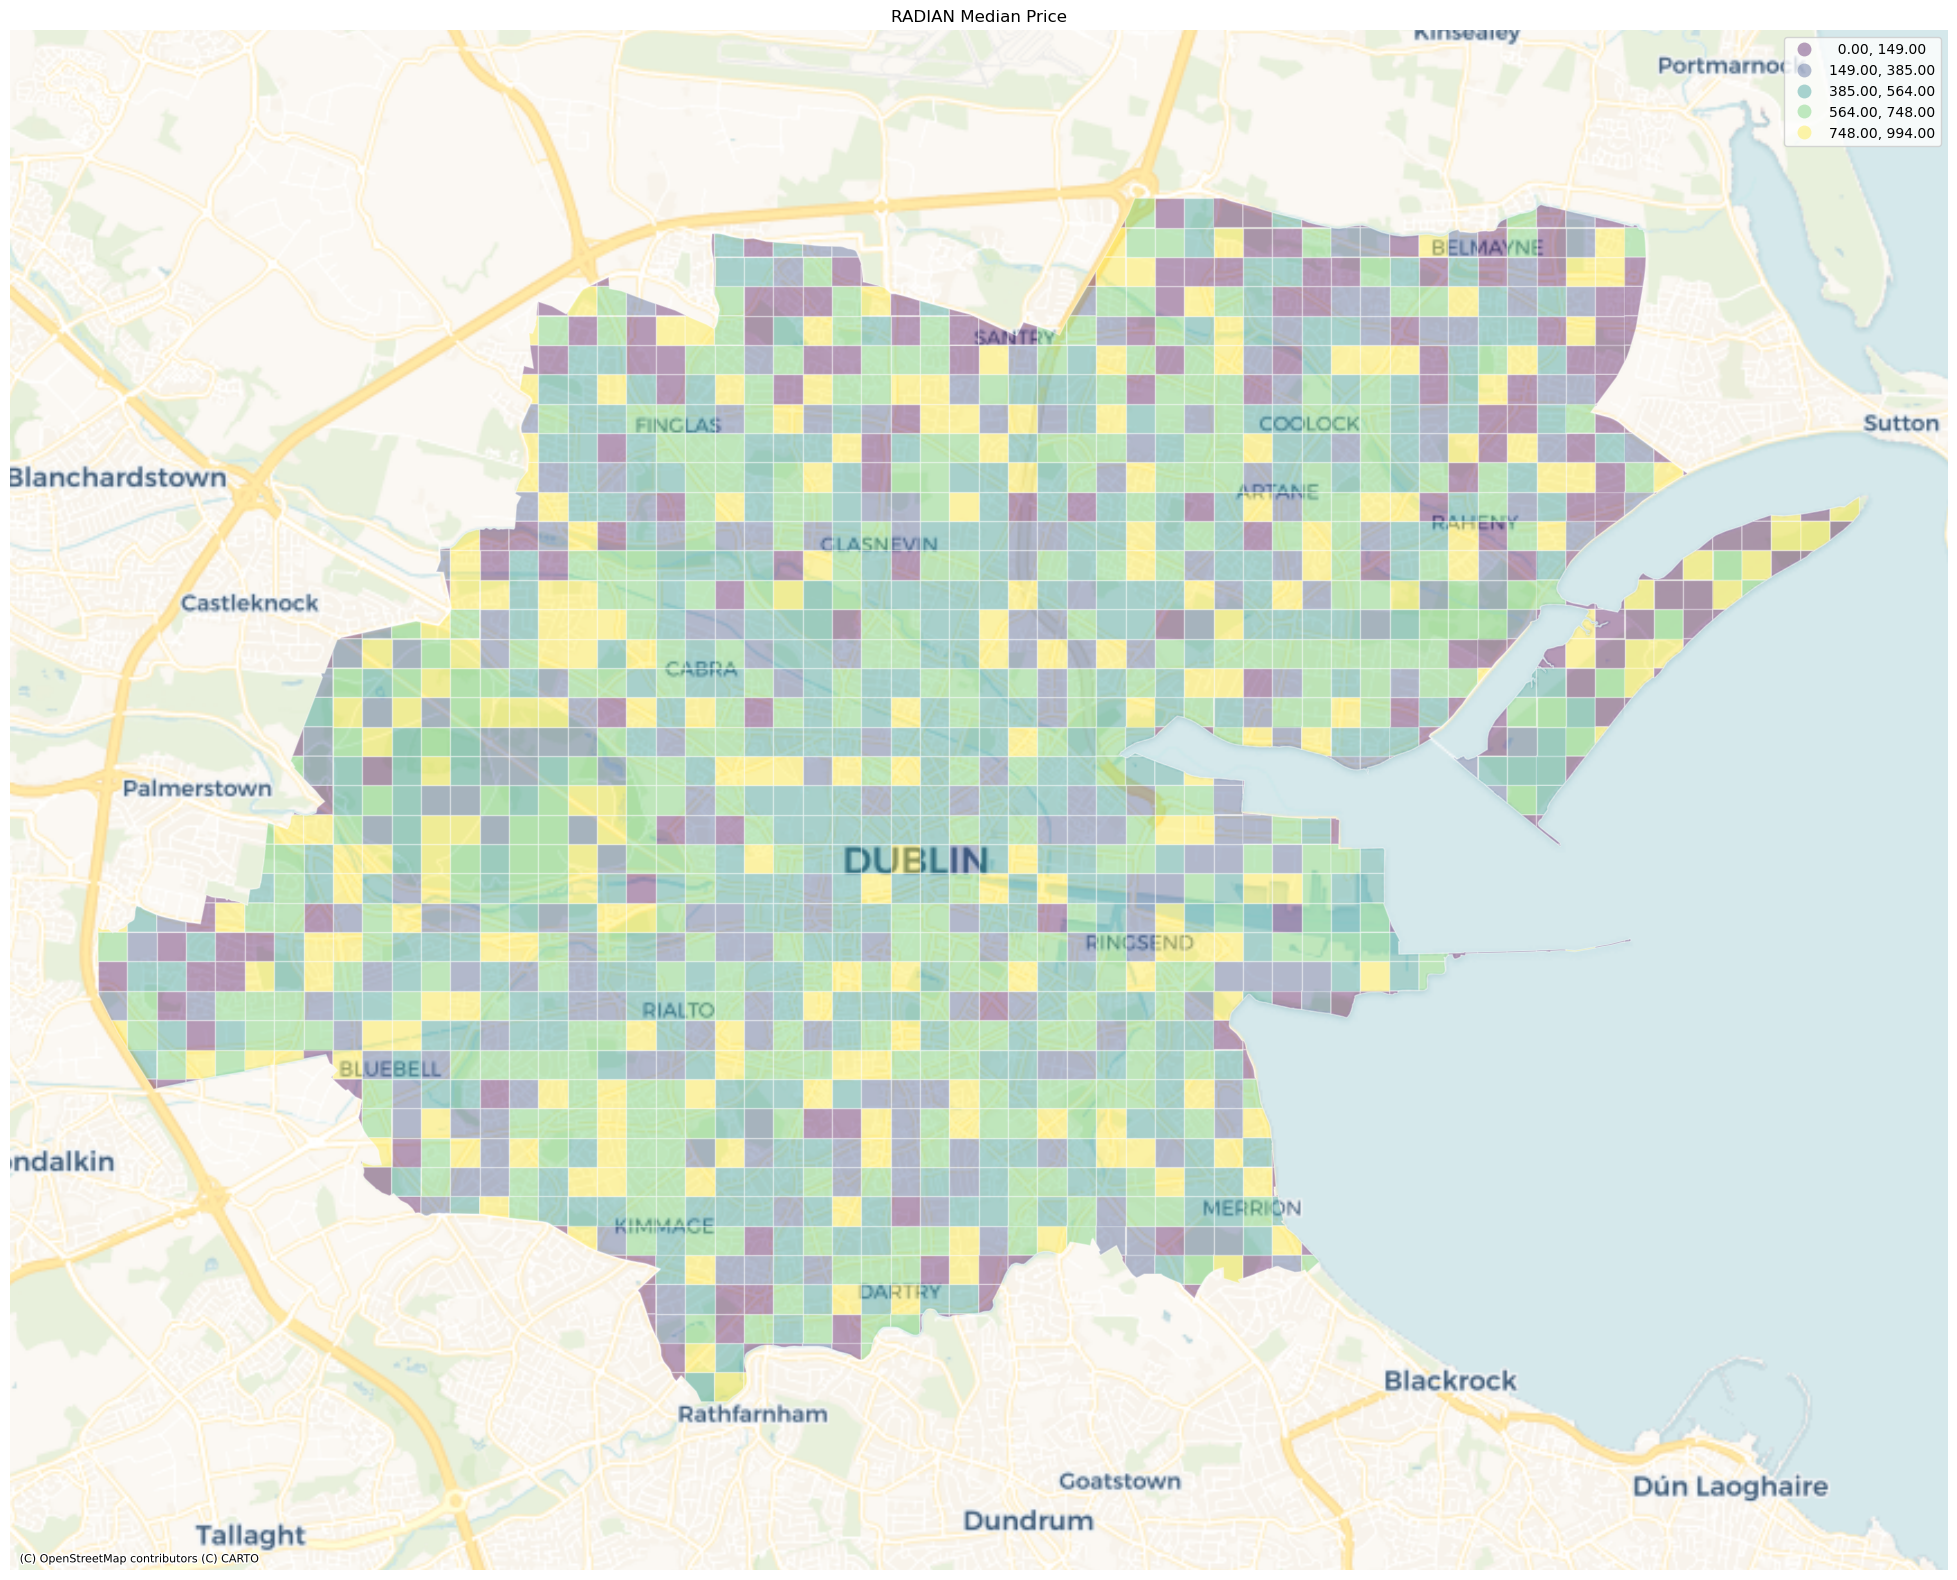

In [8]:
f, ax = plt.subplots(1, figsize=(25, 20)) #Subplots allows you to draw multiple plots in one figure
grid_clip2.to_crs('EPSG:3857').plot(ax=ax, column='MedianPrice', cmap='viridis', legend=True, scheme='FisherJenks', k=5, edgecolor='white', alpha=.38)
ax.set_axis_off() #Remove axes from plot 
ax.set_title('RADIAN Median Price') #Plot title text
plt.axis('equal') #Set x and y axes to be equal size
cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)

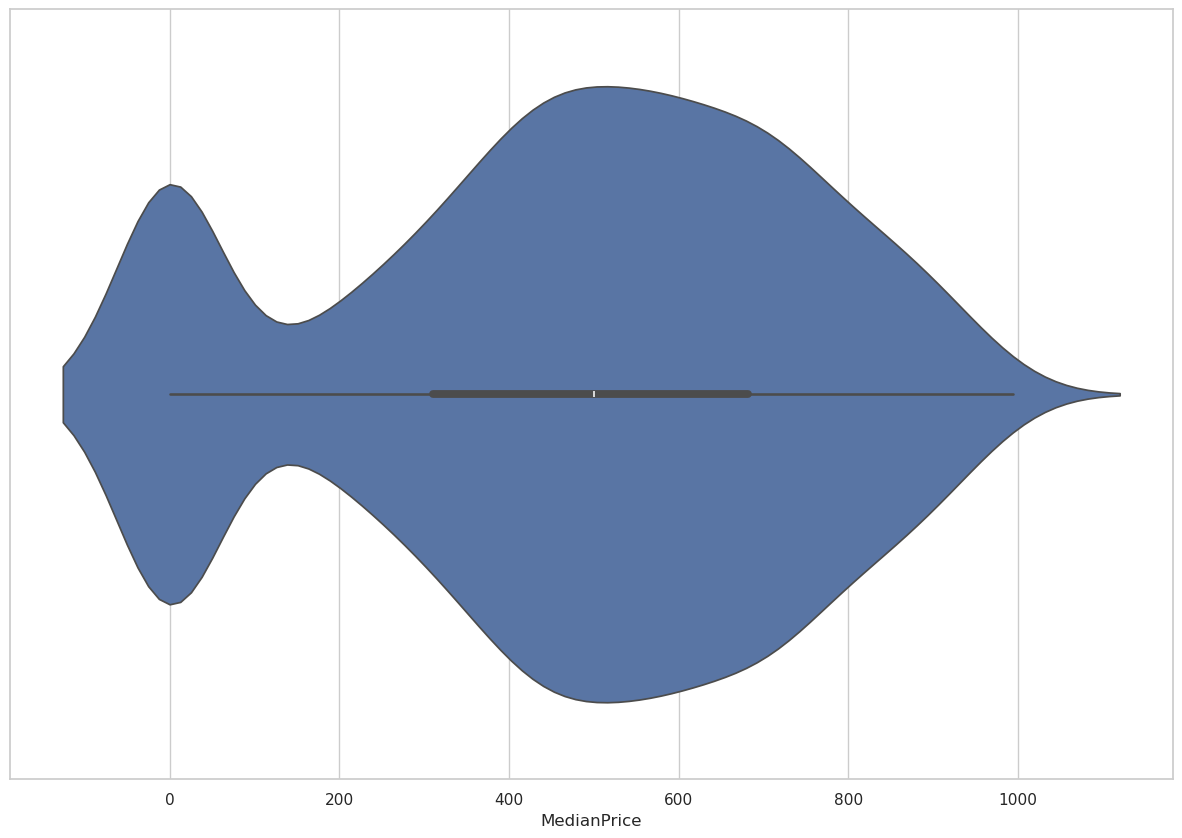

In [9]:
seaborn.set_theme(style="whitegrid")
bx = seaborn.violinplot(x=grid_clip2["MedianPrice"])

In [10]:
# Generate W from the GeoDataFrame
w = weights.Queen.from_dataframe(grid_clip2)
# Row-standardization
w.transform = 'R'

print(w.neighbors)
print(w.weights)
grid_clip2['MedianPrice_lag'] = weights.spatial_lag.lag_spatial(w, grid_clip2['MedianPrice'])


{0: [8, 1, 7], 1: [0, 2, 7, 8, 9], 2: [1, 3, 8, 9, 10], 3: [2, 4, 9, 10, 11], 4: [11, 10, 3], 5: [12, 13, 6], 6: [5, 7, 12, 13, 14], 7: [0, 1, 6, 8, 13, 14, 15], 8: [0, 1, 2, 7, 9, 14, 15, 16], 9: [1, 2, 3, 8, 10, 15, 16, 17], 10: [2, 3, 4, 9, 11, 16, 17, 18], 11: [17, 18, 3, 4, 10], 12: [19, 20, 5, 6, 13], 13: [5, 6, 7, 12, 14, 19, 20, 21], 14: [6, 7, 8, 13, 15, 20, 21, 22], 15: [7, 8, 9, 14, 16, 21, 22, 23], 16: [8, 9, 10, 15, 17, 22, 23, 24], 17: [9, 10, 11, 16, 18, 23, 24, 25], 18: [17, 24, 25, 10, 11], 19: [13, 20, 12], 20: [28, 19, 21, 27, 12, 13, 14], 21: [13, 14, 15, 20, 22, 27, 28, 29], 22: [14, 15, 16, 21, 23, 28, 29, 30], 23: [15, 16, 17, 22, 24, 29, 30, 31], 24: [32, 16, 17, 18, 23, 25, 30, 31], 25: [32, 33, 17, 18, 24, 26, 31], 26: [32, 33, 25], 27: [34, 35, 20, 21, 28], 28: [34, 35, 36, 20, 21, 22, 27, 29], 29: [35, 36, 37, 21, 22, 23, 28, 30], 30: [36, 37, 38, 22, 23, 24, 29, 31], 31: [32, 37, 38, 39, 23, 24, 25, 30], 32: [33, 38, 39, 24, 25, 26, 31], 33: [32, 25, 26], 3

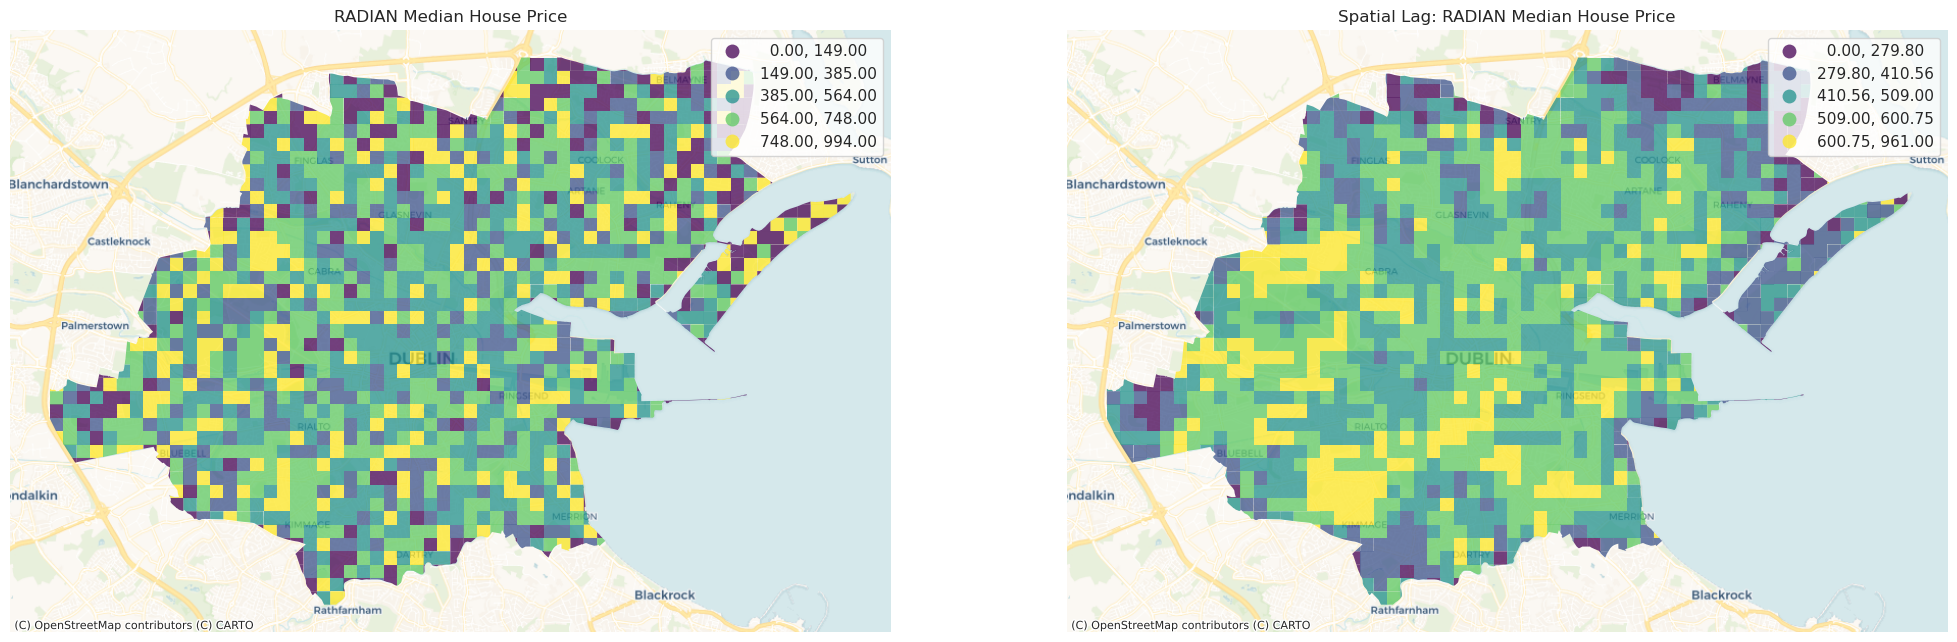

In [11]:
f, axs = plt.subplots(1, 2, figsize=(25, 20))
ax1, ax2 = axs

grid_clip2.to_crs('EPSG:3857').plot(column='MedianPrice', cmap='viridis', scheme='FisherJenks',
        k=5, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax1)
ax1.set_axis_off()
ax1.set_title("RADIAN Median House Price")
cx.add_basemap(ax1, source=cx.providers.CartoDB.Voyager)

grid_clip2.to_crs('EPSG:3857').plot(column='MedianPrice_lag', cmap='viridis', scheme='FisherJenks',
        k=5, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax2)
ax2.set_axis_off()
ax2.set_title("Spatial Lag: RADIAN Median House Price")
cx.add_basemap(ax2, source=cx.providers.CartoDB.Voyager)

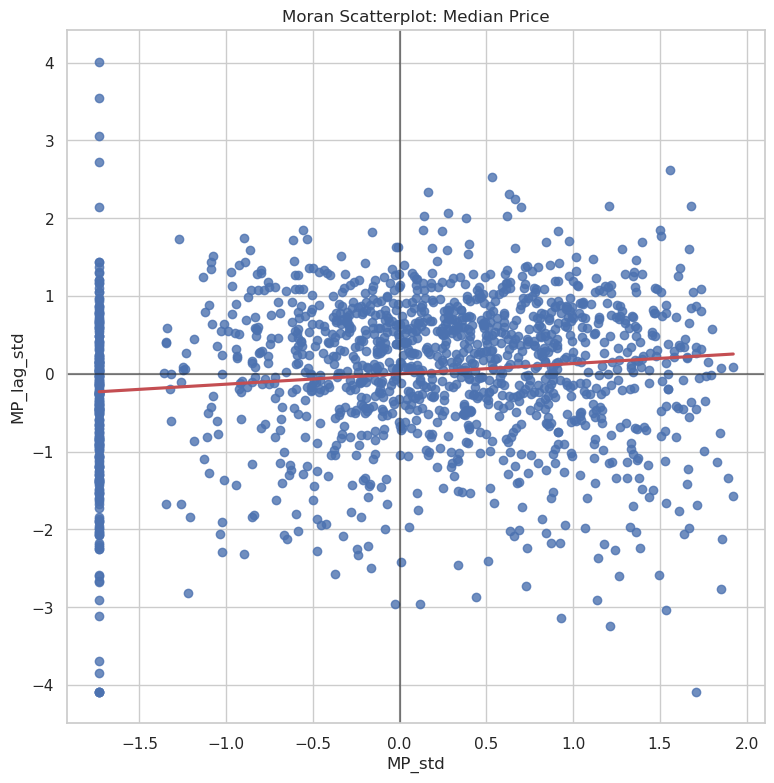

Global Moran's I =  0.05787687073438232


In [12]:
grid_clip2['MP_std'] = ( grid_clip2['MedianPrice'] - grid_clip2['MedianPrice'].mean() )\
                    / grid_clip2['MedianPrice'].std()
grid_clip2['MP_lag_std'] = ( grid_clip2['MedianPrice_lag'] - grid_clip2['MedianPrice_lag'].mean() )\
                    / grid_clip2['MedianPrice_lag'].std()

f, ax = plt.subplots(1, figsize=(9, 9))

seaborn.regplot(x='MP_std', y='MP_lag_std', 
                ci=None, data=grid_clip2, line_kws={'color':'r'})
ax.axvline(0, c='k', alpha=0.5)
ax.axhline(0, c='k', alpha=0.5)
ax.set_title('Moran Scatterplot: Median Price')
plt.show()

w.transform = 'R'
moran = esda.Moran(grid_clip2['MedianPrice'], w)
print("Global Moran's I = ", moran.I)

In [13]:
hp_sample = hp.sample(500).reset_index(drop=True)

In [14]:
import random 
from shapely.geometry import Point, box
from sklearn.cluster import KMeans

def poly_bb_ratio(poly):
    min_x, min_y, max_x, max_y = poly.bounds
    bb = gpd.GeoSeries(box(min_x, min_y, max_x, max_y, ccw=True))
    ratio = float(1/(poly.area/bb.area))
    if ratio < 1.8:
        return 1.8
    return ratio

def points_uniform(poly, num_points, epsg=4326):
    """
    Return a GeoDataFrame containing a set of uniformly distributed, random points
    set within the bounds of the given geometry.

    Works for both single and multiple geometries present in the gdf.

    @type poly: geodataframe
    @param poly: GDF containing polygons
    @type num_points: integer
    @param num_points: Number of uniform points to be generated within each geometry
    """
    points_out = gpd.GeoDataFrame(geometry=[], crs=epsg)
    
    for geom in poly.geometry:
        points_found = False   
        min_x, min_y, max_x, max_y = geom.bounds
        poly_ratio = poly_bb_ratio(geom)
        points = []
        # Generates points repeatedly with a uniform generation within the bounds of the polygon
        while len(points) < round(num_points * 3):
            points.append(Point([random.uniform(min_x, max_x), random.uniform(min_y, max_y)]))
        gdf = gpd.GeoDataFrame(pd.DataFrame(points, columns=['geometry']), geometry='geometry', crs=epsg)
        gdf = gdf.sjoin(poly, predicate='within')
        gdf = gdf[['geometry']].iloc[0:num_points].reset_index(drop=True)
        points_out = pd.concat([points_out, gdf], ignore_index=True)
    return points_out

def kmeans_centroids(poly, num_points, num_cluster):
    # Points are generated randomly in the polygon
    source = points_uniform(poly, num_points)  
        
    # The geometries of the Shapely points are converted to a numpy array for use in the kmeans algorithm
    feature_coords = np.array([[e.x, e.y] for e in source.geometry])


    # A kmeans object is created using the specified number of clusters
    kmeans = KMeans(num_cluster, random_state=1234)
    kmeans.fit(feature_coords)

    # The cluster centres are stored as centroids, and this list is put into a GeoDataFrame and returned
    centroids = kmeans.cluster_centers_
    df = pd.DataFrame(centroids, columns=['x', 'y'])
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.x, df.y))

    return gdf



In [135]:
from scipy.stats import multivariate_normal
from shapely.geometry import Point
from geovoronoi import voronoi_regions_from_coords, points_to_coords
from shapely.ops import unary_union

def voronoi_gen(poly, poly_centroid, vor_num=12, gen_type='eq', epsg=4326): #'eq', 'area', 'rand'
    # Voronoi centroids are generated based on the specified generation type
    if(gen_type == 'eq'): # Equal-area uniformly distributed Voronoi regions
        vor_centroids = kmeans_centroids(poly, 500, vor_num)
    elif(gen_type == 'area'): # Variable area, centrally focused Voronoi regions
        vor_centroids = kmeans_centroids(poly, 500, vor_num)
    elif(gen_type == 'rand'): # Equal-area uniformly distributed Voronoi regions (with moving centroid)
        # Calculate moving centroid in an eliptical region around the original centroid
        gdf_centroid = poly_centroid
        vor_centroids = kmeans_centroids(poly, 500, vor_num)
    # Setting crs to meter based projection

    # Convert the boundary geometry into a union of the polygon
    #boundary_shape = cascaded_union(poly) Depreciated
    boundary_shape = unary_union(poly.geometry)
    coords = points_to_coords(vor_centroids.geometry)

    # Calculating the voronoi regions
    region_polys, region_pts = voronoi_regions_from_coords(coords, boundary_shape)


    df = pd.DataFrame(list(region_polys.items()), columns=['index','geometry'])
    gdf_poly = gpd.GeoDataFrame(df, geometry='geometry', crs=epsg)
    return gdf_poly[['geometry']].reset_index(drop=True)

def gaussian_centre(poly, num_points, var_range=(250000, 500000), sd_scale=5, var_scale=8, epsg=3857):
    """
    3D Covariance matrix
    [[var(x), cov(x, y), cov(x,z)],
     [cov(x,y), var(y), cov(y,z)],
     [cov(x,z), cov(y,z), var(z)]
    ]
    """
    points_out = gpd.GeoDataFrame(geometry=[], crs=epsg)

    for geom in poly.geometry:
        points_found = False
        cx, cy = geom.centroid.x, geom.centroid.y
        min_x, min_y, max_x, max_y = geom.bounds
        min_x -= cx
        min_y -= cy
        max_x -= cx
        max_y -= cy

        mean_z = random.uniform(var_range[0], var_range[1])
        sd_y = (max_y - min_y)/ sd_scale
        sd_x = (max_x - min_x)/sd_scale
        sd_z = mean_z / var_scale
        var_x = sd_x **2
        var_y = sd_y **2
        var_z = sd_z **2
        cov_xz = mean_z * 3
        cov_yz = mean_z * 3
        cov_xy = 0
        # sd_y**2
        cov = np.array([[var_x,         cov_xy,          cov_xz], 
                        [cov_xy,         var_y,          cov_yz], 
                        [cov_xz,    cov_yz,     var_z]])
        # running into occasional problem, where the spatial join removes too many points
        # simple workaround for now is to just repeat the process when this happens
        # such is the nature of random generation

        pts = pd.DataFrame(np.random.multivariate_normal(mean=[cx, cy, mean_z], cov=cov, size=int(round(num_points*4))), columns=['x','y','housePrice'])
        geo_pts = gpd.GeoDataFrame(pts, geometry=gpd.points_from_xy(pts['x'], pts['y'], crs=epsg))
        geo_pts = geo_pts.sjoin(gpd.GeoDataFrame(geometry=gpd.GeoSeries([geom]), crs=epsg), predicate='within').drop(['x', 'y', 'index_right'], axis=1)
        if num_points < len(geo_pts):
            geo_pts = geo_pts.sample(num_points)
            points_found = True
        points_out = pd.concat([points_out, geo_pts], ignore_index=True)
    return points_out.reset_index(drop=True)


def morans_testing(gdf_test, plot=True):
    hp2 = gpd.sjoin(gdf_test,grid_clip)
    hp3 = hp2.groupby('ID2').agg({'housePrice':'median','id':'count'})
    hp3.columns = ['MedianPrice','House_Count']
    hp3 = hp3.reset_index()

    grid_clip2 = grid_clip.merge(hp3, how='outer')
    grid_clip2['MedianPrice'] = grid_clip2['MedianPrice'].fillna(0) #Fill median house price NAs w/0
    grid_clip2['House_Count'] = grid_clip2['House_Count'].fillna(0) #Fill house count NAs w/0
    grid_clip2 = grid_clip2.set_crs(epsg=3857)
    grid_clip2.to_crs(epsg=4326)

    #seaborn.set_theme(style="whitegrid")
    #bx = seaborn.violinplot(x=grid_clip2["MedianPrice"])

    # Generate W from the GeoDataFrame
    w = weights.Queen.from_dataframe(grid_clip2)
    # Row-standardization
    w.transform = 'R'

    grid_clip2['MedianPrice_lag'] = weights.spatial_lag.lag_spatial(w, grid_clip2['MedianPrice'])

    grid_clip2['MP_std'] = ( grid_clip2['MedianPrice'] - grid_clip2['MedianPrice'].mean() )\
                    / grid_clip2['MedianPrice'].std()
    grid_clip2['MP_lag_std'] = ( grid_clip2['MedianPrice_lag'] - grid_clip2['MedianPrice_lag'].mean() )\
                    / grid_clip2['MedianPrice_lag'].std()

    w.transform = 'R'
    moran = esda.Moran(grid_clip2['MedianPrice'], w)
    if plot:
        f, axs = plt.subplots(1, 2, figsize=(25, 20))
        ax1, ax2 = axs

        grid_clip2.to_crs('EPSG:3857').plot(column='MedianPrice', cmap='viridis', scheme='FisherJenks',
                k=5, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax1)
        ax1.set_axis_off()
        ax1.set_title("RADIAN Median House Price")
        cx.add_basemap(ax1, source=cx.providers.CartoDB.Voyager)
        
        grid_clip2.to_crs('EPSG:3857').plot(column='MedianPrice_lag', cmap='viridis', scheme='FisherJenks',
                k=5, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax2)
        ax2.set_axis_off()
        ax2.set_title("Spatial Lag: RADIAN Median House Price")
        cx.add_basemap(ax2, source=cx.providers.CartoDB.Voyager)

        print(w.neighbors)
        print(w.weights)

        f, ax = plt.subplots(1, figsize=(6, 6))

        seaborn.regplot(x='MP_std', y='MP_lag_std', 
                        ci=None, data=grid_clip2, line_kws={'color':'r'})
        ax.axvline(0, c='k', alpha=0.5)
        ax.axhline(0, c='k', alpha=0.5)
        ax.set_title('Moran Scatterplot: Median Price')
        plt.show()


        print("Global Moran's I = ", moran.I, " - sig: ", moran.p_sim)
    return moran.I



                                            geometry
0  POLYGON ((-707351.195 7049281.206, -707519.477...
1  POLYGON ((-695007.062 7057030.74, -694659.593 ...
2  POLYGON ((-690997.371 7043618.331, -690960.725...
{0: [8, 1, 7], 1: [0, 2, 7, 8, 9], 2: [1, 3, 8, 9, 10], 3: [2, 4, 9, 10, 11], 4: [11, 10, 3], 5: [12, 13, 6], 6: [5, 7, 12, 13, 14], 7: [0, 1, 6, 8, 13, 14, 15], 8: [0, 1, 2, 7, 9, 14, 15, 16], 9: [1, 2, 3, 8, 10, 15, 16, 17], 10: [2, 3, 4, 9, 11, 16, 17, 18], 11: [17, 18, 3, 4, 10], 12: [19, 20, 5, 6, 13], 13: [5, 6, 7, 12, 14, 19, 20, 21], 14: [6, 7, 8, 13, 15, 20, 21, 22], 15: [7, 8, 9, 14, 16, 21, 22, 23], 16: [8, 9, 10, 15, 17, 22, 23, 24], 17: [9, 10, 11, 16, 18, 23, 24, 25], 18: [17, 24, 25, 10, 11], 19: [13, 20, 12], 20: [28, 19, 21, 27, 12, 13, 14], 21: [13, 14, 15, 20, 22, 27, 28, 29], 22: [14, 15, 16, 21, 23, 28, 29, 30], 23: [15, 16, 17, 22, 24, 29, 30, 31], 24: [32, 16, 17, 18, 23, 25, 30, 31], 25: [32, 33, 17, 18, 24, 26, 31], 26: [32, 33, 25], 27: [34, 35, 20, 21

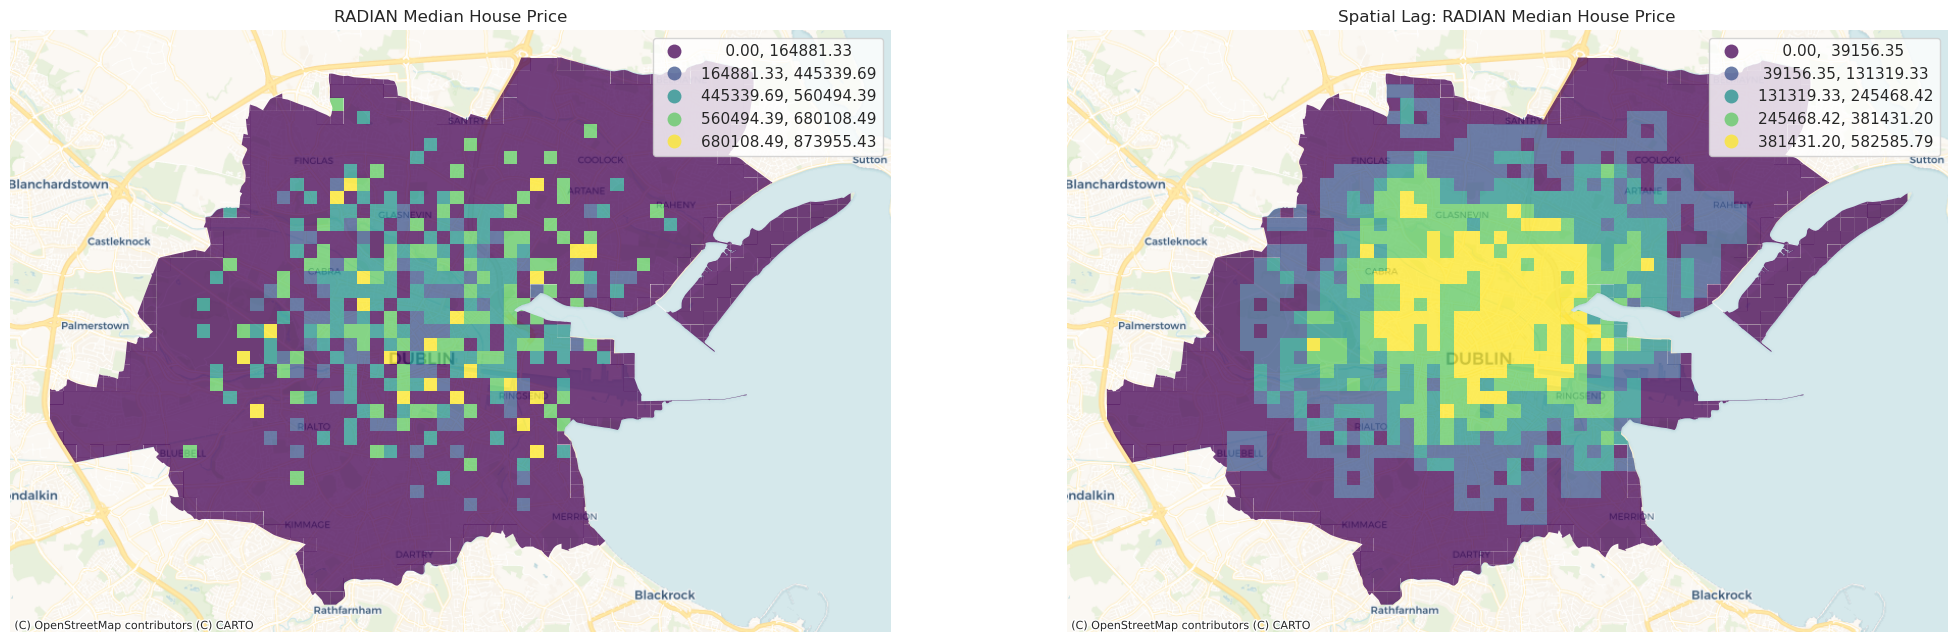

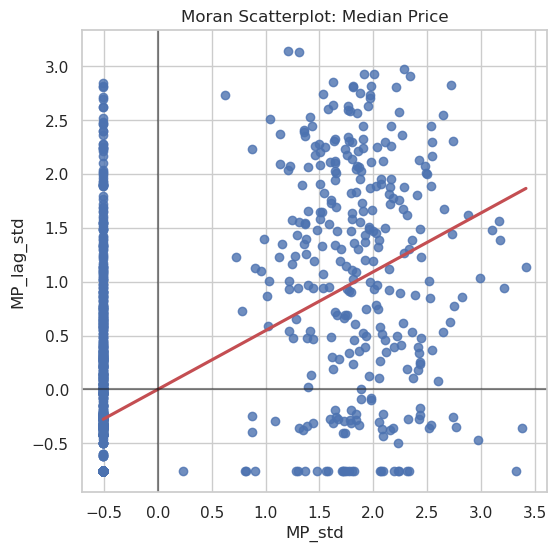

Global Moran's I =  0.3662847855576606  - sig:  0.001


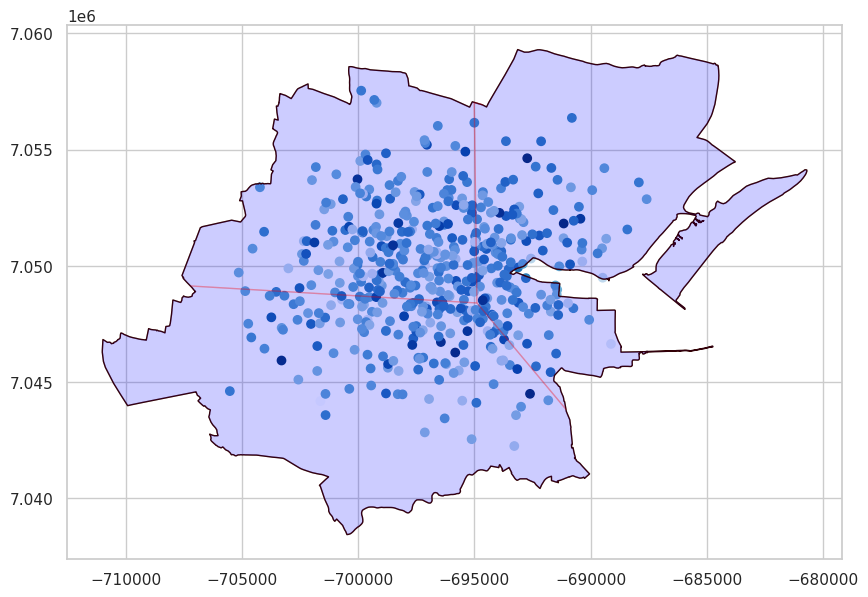

np.float64(0.3662847855576606)

In [133]:
def moran_debug(pts, vor_pts, vor_num, vor_sd_scale, vor_var_scale, vor_var_range, sd_scale, var_scale, var_range, plot=False):
    dublin_vor = voronoi_gen(dublin, dublin.centroid, vor_num, epsg=3857)
    print(dublin_vor)
    gdf_dublin = gaussian_centre(dublin, num_points=pts, var_range=var_range, sd_scale=sd_scale, var_scale=var_scale)
    gdf_vor = gaussian_centre(dublin_vor, num_points=vor_pts, var_range=vor_var_range, sd_scale=vor_sd_scale)


    gdf_test = pd.concat([gdf_dublin, gdf_vor], ignore_index=True).reset_index(drop=True).reset_index(names='id')

    gdf_moran = morans_testing(gdf_test, plot=True)
    if plot:
        fig, ax = plt.subplots(1,1,figsize=(10,8))

        gdf_test.plot(ax=ax, column=gdf_test['housePrice'], cmap='Blues')
        dublin.plot(ax=ax, edgecolor='black', facecolor='none')
        dublin_vor.plot(ax=ax, edgecolor='red', facecolor='blue', alpha=0.2)
        plt.show()
    return gdf_moran


moran_debug(pts=500, vor_pts=0, vor_num=3, vor_sd_scale=4, vor_var_scale=8, vor_var_range=(250000, 500000),
             sd_scale=8, var_scale=4, var_range=(450000, 650000), plot=True)


In [137]:
def moran_layers(pts, var_ranges, sd_scales, var_scales, plot=True):
    gdf_dublin_a = gaussian_centre(dublin, num_points=pts[0], var_range=var_ranges[0], sd_scale=sd_scales[0], var_scale=var_scales[0])
    gdf_dublin_b = gaussian_centre(dublin, num_points=pts[1], var_range=var_ranges[1], sd_scale=sd_scales[1], var_scale=var_scales[1])
    gdf_dublin_c = gaussian_centre(dublin, num_points=pts[2], var_range=var_ranges[2], sd_scale=sd_scales[2], var_scale=var_scales[2])

    gdf_test = pd.concat([gdf_dublin_a, gdf_dublin_b, gdf_dublin_c], ignore_index=True).reset_index(drop=True).reset_index(names='id')

    gdf_moran = morans_testing(gdf_test, plot=plot)
    if plot:
        fig, ax = plt.subplots(1,1,figsize=(10,8))
        gdf_dublin_c.plot(ax=ax, color='green')
        #gdf_dublin_b.plot(ax=ax, column=gdf_test['housePrice'], cmap='Blues')
        gdf_dublin_a.plot(ax=ax, color='red')

        dublin.plot(ax=ax, edgecolor='black', facecolor='none')
        plt.show()
    return gdf_moran


moran_i = []
for i in range(100):
    i_I  = moran_layers(pts=(25000,0,10000),
             var_ranges=[(500000,750000),(450000, 650000),(175000, 250000)],
             sd_scales=(30, 2, 2), var_scales=(8,4,4), plot=False)
    moran_i.append(i_I)

print("Mean Moran's I = ", np.mean(moran_i))


Mean Moran's I =  0.6813989263766009
